In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Check pre-installed torch and cuda versions in Kaggle environment
import torch
print(torch.__version__, torch.cuda.is_available())

# Install dependencies, ensuring the PyYAML version is compatible
!pip install pyyaml==5.1
!pip install -U 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'


2.9.0+cu126 True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 6.4 MB/s eta 0:00:00a 0:00:01
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  Cloning https://github.com/cocodataset/cocoapi.git to /tmp/pip-req-build-w9wtkto8
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/cocoapi.git /tmp/pip-req-build-w9wtkto8
  Resolved https://github.com/cocodataset/cocoapi.git to commit 8c9bcc3cf640524c4c20a9c40e89cb6a2f2fa0e9
  Preparing metadata (setup.py) ... done
  Created wheel for pycocotools: filename=pycocotool

In [2]:
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'


  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-6zj36ce7
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-6zj36ce7
  Resolved https://github.com/facebookresearch/detectron2.git to commit 8a9d885b3d4dcf1bef015f0593b872ed8d32b4ab
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.7/411.7 kB 17.1 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7084965 sha256=35b1210b113507d0a59c60e67cd6a3dee882006601ee220611c61c71d273a1d2
  Stored in directory: /tmp/pip-ephem-wheel-cache-7d90wpg5/wheels/d3/6e/bd/1969578f1456a6be2d6f083da65c669f450b23b8f3d1ac14c1
  Created wheel for fvcore: filename=fvcor

In [3]:
TOP5 = [
    "short sleeve top",
    "long sleeve top",
    "shorts",
    "trousers",
    "skirt"
]

In [4]:
def load_fashion(image_dir, anno_dir):

    dataset_dicts = []

    files = [f for f in os.listdir(anno_dir) if f.endswith(".json")]

    for idx, file in enumerate(tqdm(files)):

        anno_path = os.path.join(anno_dir, file)
        img_path = os.path.join(image_dir, file.replace(".json", ".jpg"))

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]

        with open(anno_path) as f:
            data = json.load(f)

        record = {}
        record["file_name"] = img_path
        record["image_id"] = idx
        record["height"] = h
        record["width"] = w

        objs = []

        for key in data:
            if not key.startswith("item"):
                continue

            item = data[key]
            cat = item["category_name"]

            if cat not in TOP5:
                continue

            bbox = item["bounding_box"]
            seg = item["segmentation"]

            if len(seg) == 0:
                continue

            try:
                poly = seg[0]
            except:
                continue

            obj = {
                "bbox": bbox,
                "bbox_mode": BoxMode.XYXY_ABS,
                "category_id": TOP5.index(cat),
                "segmentation": [poly],
                "iscrowd": 0
            }

            objs.append(obj)

        if len(objs) == 0:
            continue

        record["annotations"] = objs
        dataset_dicts.append(record)

    return dataset_dicts

In [5]:
import os
import json
import cv2
from tqdm import tqdm

from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

In [6]:
train_images = "/kaggle/input/datasets/varun000reddy/training-50k/train_50k/images"
train_annos  = "/kaggle/input/datasets/varun000reddy/training-50k/train_50k/annos"

val_images = "/kaggle/input/datasets/varun000reddy/validation/validation/image"
val_annos  = "/kaggle/input/datasets/varun000reddy/validation/validation/annos"

# REMOVE OLD REGISTRATION (IMPORTANT)
from detectron2.data import DatasetCatalog

if "fashion_train" in DatasetCatalog.list():
    DatasetCatalog.remove("fashion_train")
if "fashion_val" in DatasetCatalog.list():
    DatasetCatalog.remove("fashion_val")

DatasetCatalog.register(
    "fashion_train",
    lambda: load_fashion(train_images, train_annos)
)

DatasetCatalog.register(
    "fashion_val",
    lambda: load_fashion(val_images, val_annos)
)

MetadataCatalog.get("fashion_train").set(thing_classes=TOP5)
MetadataCatalog.get("fashion_val").set(thing_classes=TOP5)

namespace(name='fashion_val',
          thing_classes=['short sleeve top',
                         'long sleeve top',
                         'shorts',
                         'trousers',
                         'skirt'])

In [18]:
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()

cfg.merge_from_file(
    model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
)

cfg.DATASETS.TRAIN = ("fashion_train",)
cfg.DATASETS.TEST = ("fashion_val",)

cfg.DATALOADER.NUM_WORKERS = 2

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
)

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025

cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(TOP5)

cfg.OUTPUT_DIR = "/kaggle/working/output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
cfg.DATALOADER.SAMPLER_TRAIN = "RepeatFactorTrainingSampler"
cfg.DATALOADER.REPEAT_THRESHOLD = 0.005

cfg.SOLVER.MAX_ITER = 80000
cfg.SOLVER.CHECKPOINT_PERIOD = 10000



In [15]:
from detectron2.engine import DefaultTrainer

trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)

trainer.train()

[03/17 12:22:04 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

100%|██████████| 49980/49980 [14:02<00:00, 59.30it/s]  

[03/17 12:36:07 d2.data.build]: Removed 0 images with no usable annotations. 37561 images left.


[03/17 12:36:08 d2.data.build]: Distribution of instances among all 5 categories:
|   category    | #instances   |   category    | #instances   |  category  | #instances   |
|:-------------:|:-------------|:-------------:|:-------------|:----------:|:-------------|
| short sleev.. | 18670        | long sleeve.. | 9388         |   shorts   | 9543         |
|   trousers    | 14442        |     skirt     | 8032         |            |              |
|     total     | 60075        |               |              |            |              |
[03/17 12:36:08 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in training: [ResizeShortestEdge(short_edge_length=(640, 672, 704, 736, 768, 800), max_size=1333, sample_style='choice'), RandomFlip()]
[03/17 12:36:08 d2.data.build]: Using training sampler TrainingSampler
[03/17 12:36:08 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[03/17 12:36:08 d2.data.common]: Serializing 37561 elemen

model_final_f10217.pkl: 178MB [00:00, 269MB/s]                             
Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (6, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (6,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (20, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (20,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due t

...

[03/17 12:36:22 d2.utils.events]:  eta: 1:15:24  iter: 19  total_loss: 2.658  loss_cls: 1.784  loss_box_reg: 0.1493  loss_mask: 0.6935  loss_rpn_cls: 0.01694  loss_rpn_loc: 0.01562    time: 0.4619  last_time: 0.4922  data_time: 0.0155  last_data_time: 0.0051   lr: 4.9953e-06  max_mem: 2580M


2026-03-17 12:36:25.051626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773750985.260861      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773750985.329074      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773750985.846665      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773750985.846707      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773750985.846710      55 computation_placer.cc:177] computation placer alr

[03/17 12:36:55 d2.utils.events]:  eta: 1:18:35  iter: 39  total_loss: 2.49  loss_cls: 1.617  loss_box_reg: 0.1296  loss_mask: 0.6932  loss_rpn_cls: 0.02385  loss_rpn_loc: 0.01382    time: 0.4663  last_time: 0.3716  data_time: 0.0059  last_data_time: 0.0033   lr: 9.9902e-06  max_mem: 2669M
[03/17 12:37:04 d2.utils.events]:  eta: 1:16:21  iter: 59  total_loss: 2.251  loss_cls: 1.319  loss_box_reg: 0.1447  loss_mask: 0.6923  loss_rpn_cls: 0.01963  loss_rpn_loc: 0.01611    time: 0.4593  last_time: 0.4485  data_time: 0.0050  last_data_time: 0.0054   lr: 1.4985e-05  max_mem: 2669M
[03/17 12:37:13 d2.utils.events]:  eta: 1:17:49  iter: 79  total_loss: 1.891  loss_cls: 0.959  loss_box_reg: 0.1499  loss_mask: 0.6882  loss_rpn_cls: 0.02781  loss_rpn_loc: 0.01286    time: 0.4662  last_time: 0.4403  data_time: 0.0053  last_data_time: 0.0049   lr: 1.998e-05  max_mem: 2669M
[03/17 12:37:23 d2.utils.events]:  eta: 1:18:22  iter: 99  total_loss: 1.498  loss_cls: 0.6097  loss_box_reg: 0.1384  loss_mas

100%|██████████| 32153/32153 [14:28<00:00, 37.04it/s]


[03/17 14:18:29 d2.data.build]: Distribution of instances among all 5 categories:
|   category    | #instances   |   category    | #instances   |  category  | #instances   |
|:-------------:|:-------------|:-------------:|:-------------|:----------:|:-------------|
| short sleev.. | 12556        | long sleeve.. | 5966         |   shorts   | 4167         |
|   trousers    | 9586         |     skirt     | 6522         |            |              |
|     total     | 38797        |               |              |            |              |
[03/17 14:18:29 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[03/17 14:18:29 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[03/17 14:18:29 d2.data.common]: Serializing 23741 elements to byte tensors and concatenating them all ...
[03/17 14:18:30 d2.data.common]: Serialized dataset ta

In [ ]:
from detectron2.engine import DefaultTrainer

trainer = DefaultTrainer(cfg)

# 🔥 THIS IS CRITICAL
trainer.resume_or_load(resume=True)

trainer.train()

[03/17 14:20:51 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

100%|██████████| 49980/49980 [05:34<00:00, 149.44it/s]

[03/17 14:26:25 d2.data.build]: Removed 0 images with no usable annotations. 37561 images left.


[03/17 14:26:26 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in training: [ResizeShortestEdge(short_edge_length=(640, 672, 704, 736, 768, 800), max_size=1333, sample_style='choice'), RandomFlip()]
[03/17 14:26:26 d2.data.build]: Using training sampler RepeatFactorTrainingSampler
[03/17 14:26:26 d2.data.samplers.distributed_sampler]: Cat ID 0: freq=0.49, rep=1.00
[03/17 14:26:26 d2.data.samplers.distributed_sampler]: Cat ID 1: freq=0.25, rep=1.00
[03/17 14:26:26 d2.data.samplers.distributed_sampler]: Cat ID 2: freq=0.25, rep=1.00
[03/17 14:26:26 d2.data.samplers.distributed_sampler]: Cat ID 3: freq=0.38, rep=1.00
[03/17 14:26:26 d2.data.samplers.distributed_sampler]: Cat ID 4: freq=0.21, rep=1.00
[03/17 14:26:26 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[03/17 14:26:26 d2.data.common]: Serializing 37561 elements to byte tensors and concatenating them all ...
[03/17 14:26:27 d2.data.common]: Serialized dataset tak

In [8]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
)

cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(TOP5)
cfg.MODEL.WEIGHTS = "/kaggle/working/output/model_final.pth"  # your trained model
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = "cuda"

predictor = DefaultPredictor(cfg)

In [9]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator(
    "fashion_val",
    tasks=("bbox","segm"),
    distributed=False,
    output_dir="./output"
)

val_loader = build_detection_test_loader(cfg, "fashion_val")

results = inference_on_dataset(
    DefaultPredictor(cfg).model,
    val_loader,
    evaluator
)

print(results)

100%|██████████| 32153/32153 [11:48<00:00, 45.41it/s]
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0324 10:29:29.713000 55 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.516
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.704
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.606
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.647
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.477
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.518
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.626
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.633
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.633
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.648
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.508
 Average Recall     (AR) @[ IoU=0.50:0.

In [26]:
class_names = [
     "short sleeve top",
    "long sleeve top",
    "shorts",
    "trousers",
    "skirt"
]

In [38]:
import cv2
import numpy as np

image = cv2.imread("/kaggle/input/datasets/varun000reddy/testing/test/test/image/000040.jpg")

outputs = predictor(image)

instances = outputs["instances"].to("cpu")

pred_classes = instances.pred_classes.numpy()
pred_masks = instances.pred_masks.numpy()
scores = instances.scores.numpy()

In [39]:
mapped_labels = pred_classes + 1  # shift by +1

for i in range(len(mapped_labels)):
    print(f"Object {i}:")
    print("  Class ID:", mapped_labels[i])
    print("  Class Name:", class_names[pred_classes[i]])
    print("  Score:", scores[i])

Object 0:
  Class ID: 2
  Class Name: long sleeve top
  Score: 0.5221257


In [40]:
H, W = image.shape[:2]
seg_map = np.zeros((H, W), dtype=np.uint8)

for i in range(len(pred_masks)):
    seg_map[pred_masks[i] == True] = mapped_labels[i]

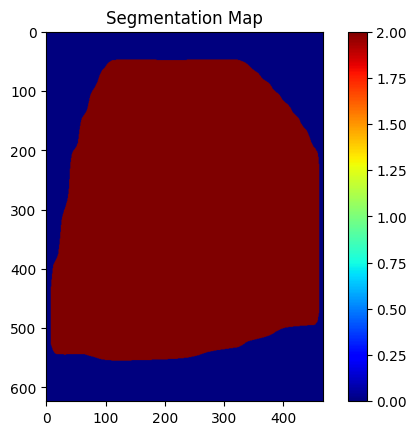

In [41]:
import matplotlib.pyplot as plt

plt.imshow(seg_map, cmap="jet")
plt.colorbar()
plt.title("Segmentation Map")
plt.show()

In [48]:
class_names = [
    "short sleeve top",
    "long sleeve top",
    "shorts",
    "trousers",
    "skirt"
]

mapped_classes = classes + 1  # shift for background

In [44]:
import cv2

image = cv2.imread("/kaggle/input/datasets/varun000reddy/testing/test/test/image/000001.jpg")

outputs = predictor(image)

instances = outputs["instances"].to("cpu")

In [45]:
boxes = instances.pred_boxes.tensor.numpy()
classes = instances.pred_classes.numpy()
scores = instances.scores.numpy()

In [49]:
import cv2

output_img = image.copy()

for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i].astype(int)
    cls_id = mapped_classes[i]
    label = class_names[cls_id]
    score = scores[i]

    cv2.rectangle(output_img, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(
        output_img,
        f"{label}: {score:.2f}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0,255,0),
        2
    )

cv2.imwrite("/kaggle/working/detection_output.jpg", output_img)

True

In [8]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()

# Use same config you trained with
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 5
cfg.MODEL.WEIGHTS = "/kaggle/working/output/model_final.pth"  # your trained model

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = "cuda"  # or "cpu"

predictor = DefaultPredictor(cfg)

In [9]:
import numpy as np
import cv2
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.utils.visualizer import GenericMask

NUM_CLASSES = 5

def compute_metrics(predictor, dataset_name):
    dataset_dicts = DatasetCatalog.get(dataset_name)

    iou_per_class = [[] for _ in range(NUM_CLASSES)]
    dice_per_class = [[] for _ in range(NUM_CLASSES)]

    for d in dataset_dicts:
        img = cv2.imread(d["file_name"])
        outputs = predictor(img)

        instances = outputs["instances"].to("cpu")

        pred_masks = instances.pred_masks.numpy()
        pred_classes = instances.pred_classes.numpy()

        # Ground truth
        gt_masks = []
        gt_classes = []

        for ann in d["annotations"]:
            mask = GenericMask(
                ann["segmentation"], d["height"], d["width"]
            ).mask
            gt_masks.append(mask)
            gt_classes.append(ann["category_id"])

        # Match GT → prediction (IoU matching)
        for gt_mask, gt_cls in zip(gt_masks, gt_classes):

            best_iou = 0
            best_dice = 0

            for pm, pc in zip(pred_masks, pred_classes):
                if pc != gt_cls:
                    continue

                intersection = np.logical_and(pm, gt_mask).sum()
                union = np.logical_or(pm, gt_mask).sum()

                iou = intersection / (union + 1e-6)
                dice = (2 * intersection) / (pm.sum() + gt_mask.sum() + 1e-6)

                if iou > best_iou:
                    best_iou = iou
                    best_dice = dice

            iou_per_class[gt_cls].append(best_iou)
            dice_per_class[gt_cls].append(best_dice)

    # Per class + macro
    print("\n=== Segmentation Metrics ===")

    mean_ious = []
    mean_dices = []

    for i in range(NUM_CLASSES):
        miou = np.mean(iou_per_class[i]) if iou_per_class[i] else 0
        mdice = np.mean(dice_per_class[i]) if dice_per_class[i] else 0

        mean_ious.append(miou)
        mean_dices.append(mdice)

        print(f"Class {i} → mIoU: {miou:.4f}, Dice: {mdice:.4f}")

    print("\nMacro mIoU:", np.mean(mean_ious))
    print("Macro Dice:", np.mean(mean_dices))

In [10]:
from sklearn.metrics import f1_score

def compute_f1(predictor, dataset_name):
    dataset_dicts = DatasetCatalog.get(dataset_name)

    y_true = []
    y_pred = []

    for d in dataset_dicts:
        img = cv2.imread(d["file_name"])
        outputs = predictor(img)

        pred_classes = outputs["instances"].pred_classes.cpu().numpy()
        gt_classes = [ann["category_id"] for ann in d["annotations"]]

        gt_vec = [0]*NUM_CLASSES
        pred_vec = [0]*NUM_CLASSES

        for c in gt_classes:
            gt_vec[c] = 1
        for c in pred_classes:
            pred_vec[c] = 1

        y_true.append(gt_vec)
        y_pred.append(pred_vec)

    f1 = f1_score(y_true, y_pred, average="macro")
    print("\nF1-score (macro):", f1)

In [11]:
from sklearn.metrics import roc_auc_score

def compute_auc(predictor, dataset_name):
    dataset_dicts = DatasetCatalog.get(dataset_name)

    y_true = []
    y_scores = []

    for d in dataset_dicts:
        img = cv2.imread(d["file_name"])
        outputs = predictor(img)

        instances = outputs["instances"].to("cpu")

        scores = instances.scores.numpy()
        pred_classes = instances.pred_classes.numpy()

        gt_classes = [ann["category_id"] for ann in d["annotations"]]

        gt_vec = [0]*NUM_CLASSES
        score_vec = [0]*NUM_CLASSES

        for c in gt_classes:
            gt_vec[c] = 1

        for s, c in zip(scores, pred_classes):
            score_vec[c] = max(score_vec[c], s)

        y_true.append(gt_vec)
        y_scores.append(score_vec)

    auc = roc_auc_score(y_true, y_scores, average="macro")
    print("AUC (macro):", auc)

In [12]:
compute_metrics(predictor, "fashion_val")
compute_f1(predictor, "fashion_val")
compute_auc(predictor, "fashion_val")

100%|██████████| 32153/32153 [12:18<00:00, 43.51it/s]
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0328 09:27:53.442000 55 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.



=== Segmentation Metrics ===
Class 0 → mIoU: 0.8283, Dice: 0.8792
Class 1 → mIoU: 0.5723, Dice: 0.6158
Class 2 → mIoU: 0.5680, Dice: 0.6196
Class 3 → mIoU: 0.7312, Dice: 0.8000
Class 4 → mIoU: 0.6732, Dice: 0.7128

Macro mIoU: 0.6745966999435302
Macro Dice: 0.7254622884238973


100%|██████████| 32153/32153 [03:15<00:00, 164.14it/s]



F1-score (macro): 0.7518086020380212


100%|██████████| 32153/32153 [03:18<00:00, 161.84it/s]


AUC (macro): 0.8574949425980073
